# Cartify - Main Data Pipeline

## 1. Import Libraries

In [1]:
import pickle as pkl
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD          # NEW: LSA to compress text dims
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, normalize  # normalize for cosine KNN


## 2. Connect to SQL Server

In [2]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=MHAMZA;"
    "DATABASE=EcommerceDB;"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
    "TrustServerCertificate=yes;"
)

## 3. Fetch All Tables

In [3]:
# pull each table from the database into a pandas DataFrame
df_products = pd.read_sql("SELECT * FROM Products", conn)
df_users = pd.read_sql("SELECT * FROM Users", conn)
df_orders = pd.read_sql("SELECT * FROM Orders", conn)
df_order_items = pd.read_sql("SELECT * FROM OrderItems", conn)
df_reviews = pd.read_sql("SELECT * FROM Reviews", conn)

print(df_products.shape, df_users.shape, df_orders.shape)

(101, 11) (17, 10) (68, 7)


C:\Users\mugha\AppData\Local\Temp\ipykernel_3708\2845597977.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql("SELECT * FROM Products", conn)
C:\Users\mugha\AppData\Local\Temp\ipykernel_3708\2845597977.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_users = pd.read_sql("SELECT * FROM Users", conn)
C:\Users\mugha\AppData\Local\Temp\ipykernel_3708\2845597977.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orders = pd.read_sql("SELECT * FROM Orders", conn)
C:\Users\mugha\AppData\Local\

## 4. Raw Data Preview

In [4]:
df_products.head()

,id,name,category,price,description,image_url,brand,rating,stock,local_image,extra_images
0,1,Wireless Headphones Pro,Electronics,4999.0,Bluetooth over-ear headphones with active nois...,https://images.unsplash.com/photo-150574042092...,SoundMax,4.5,120,products/1.jpg,https://images.unsplash.com/photo-158339483833...
1,2,Noise Cancelling Earbuds,Electronics,3999.0,True wireless earbuds with ANC and 24hr total ...,https://images.unsplash.com/photo-159065826803...,SoundMax,4.6,95,products/2.jpg,https://images.unsplash.com/photo-160622058891...
2,3,Portable Bluetooth Speaker,Electronics,3499.0,Waterproof 360-degree sound bluetooth speaker ...,https://images.unsplash.com/photo-160804315226...,SoundMax,4.5,80,products/3.jpg,https://images.unsplash.com/photo-1545454675-3...
3,4,Over-Ear Studio Headphones,Electronics,7999.0,Professional studio-grade wired headphones wit...,https://images.unsplash.com/photo-150574042092...,AudioPro,4.7,60,products/4.jpg,https://images.unsplash.com/photo-158339483833...
4,5,Sports Earphones,Electronics,1499.0,Sweat-resistant in-ear sports earphones with s...,https://images.unsplash.com/photo-151170717163...,FitSound,4.1,150,products/5.jpg,https://images.unsplash.com/photo-159289967797...


In [5]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            101 non-null    int64  
 1   name          101 non-null    str    
 2   category      101 non-null    str    
 3   price         101 non-null    float64
 4   description   101 non-null    str    
 5   image_url     101 non-null    str    
 6   brand         101 non-null    str    
 7   rating        101 non-null    float64
 8   stock         101 non-null    int64  
 9   local_image   101 non-null    str    
 10  extra_images  101 non-null    str    
dtypes: float64(2), int64(2), str(7)
memory usage: 8.8 KB


In [6]:
df_products.isnull().sum()

id              0
name            0
category        0
price           0
description     0
image_url       0
brand           0
rating          0
stock           0
local_image     0
extra_images    0
dtype: int64

## 5. Data Cleaning

### 5.1 - Clean Products Table

In [7]:
REQUIRED_COLS = ["name", "category", "brand", "description"]

# replace NULLs with empty string so TF-IDF doesn't crash later
for col in REQUIRED_COLS:
    df_products[col] = df_products[col].fillna("").str.strip()

# drop rows where all 4 text fields are empty - useless for recommendations
before = len(df_products)
mask = (
    (df_products["name"] == "") &
    (df_products["category"] == "") &
    (df_products["brand"] == "") &
    (df_products["description"] == "")
)
df_products = df_products[~mask]
print(f"dropped {before - len(df_products)} empty rows")

# convert to correct types, fill any bad values with 0
df_products["price"] = pd.to_numeric(df_products["price"], errors="coerce").fillna(0)
df_products["rating"] = pd.to_numeric(df_products["rating"], errors="coerce").fillna(0).clip(0, 5)
df_products["stock"] = pd.to_numeric(df_products["stock"], errors="coerce").fillna(0).astype(int)

df_products[["id", "name", "category", "price", "rating", "stock"]].head()

dropped 0 empty rows


,id,name,category,price,rating,stock
0,1,Wireless Headphones Pro,Electronics,4999.0,4.5,120
1,2,Noise Cancelling Earbuds,Electronics,3999.0,4.6,95
2,3,Portable Bluetooth Speaker,Electronics,3499.0,4.5,80
3,4,Over-Ear Studio Headphones,Electronics,7999.0,4.7,60
4,5,Sports Earphones,Electronics,1499.0,4.1,150


### 5.2 - Clean Orders Table

In [8]:
# address and phone are NULL on old orders - that's fine, just fill with empty string
df_orders["address"] = df_orders["address"].fillna("").str.strip()
df_orders["phone"] = df_orders["phone"].fillna("").str.strip()

# normalize status so "Pending" and "pending" don't count as different
df_orders["status"] = df_orders["status"].str.strip().str.lower()
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"], errors="coerce")

df_orders["status"].value_counts()

status
delivered     36
placed        12
processing    11
shipped        8
cancelled      1
Name: count, dtype: int64

### 5.3 - Clean Users Table

In [9]:
df_users["reset_token"] = df_users["reset_token"].fillna("")

# these columns were added later so they might not exist on older DBs
if "reset_token_expires" in df_users.columns:
    df_users["reset_token_expires"] = pd.to_datetime(df_users["reset_token_expires"], errors="coerce")
if "profile_image" in df_users.columns:
    df_users["profile_image"] = df_users["profile_image"].fillna("")

# drop sensitive columns before using users data anywhere
drop_cols = ["password", "reset_token", "reset_token_expires"]
df_users_clean = df_users.drop(columns=[c for c in drop_cols if c in df_users.columns])
df_users_clean.head()

,id,name,email,role,created_at,status,profile_image
0,1,Admin User,admin@smartshop.com,admin,2026-06-04 13:18:08.020,active,uploads/profile_pictures/user_1_786a5cc5951d7a...
1,2,Ali Hassan,ali@test.com,customer,2026-06-04 13:18:08.020,active,
2,3,Sara Ahmed,sara@test.com,customer,2026-06-04 13:18:08.020,banned,
3,4,Usman Khan,usman@test.com,customer,2026-06-04 13:18:08.020,active,
4,5,Fatima Malik,fatima@test.com,customer,2026-06-04 13:18:08.020,active,


### 5.4 - Clean Reviews & OrderItems

In [10]:
df_reviews["comment"] = df_reviews["comment"].fillna("").str.strip()
df_reviews["rating"] = pd.to_numeric(df_reviews["rating"], errors="coerce").fillna(0).clip(1, 5).astype(int)
df_reviews["created_at"] = pd.to_datetime(df_reviews["created_at"], errors="coerce")

df_order_items["quantity"] = pd.to_numeric(df_order_items["quantity"], errors="coerce").fillna(1).astype(int)
df_order_items["price"] = pd.to_numeric(df_order_items["price"], errors="coerce").fillna(0)

print("cleaning done")

cleaning done


## 6. Exploratory Data Analysis (EDA)

C:\Users\mugha\AppData\Local\Temp\ipykernel_3708\2944199331.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


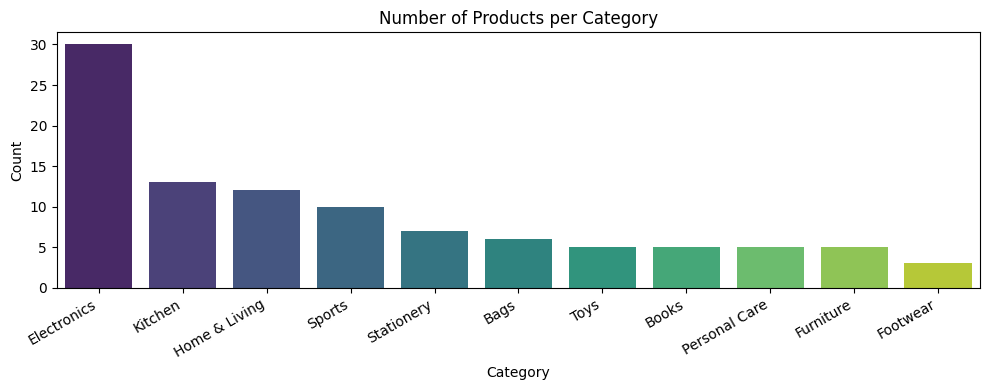

In [11]:
plt.figure(figsize=(10, 4))
category_counts = df_products["category"].value_counts()
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.title("Number of Products per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

C:\Users\mugha\AppData\Local\Temp\ipykernel_3708\4211387800.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="coolwarm")


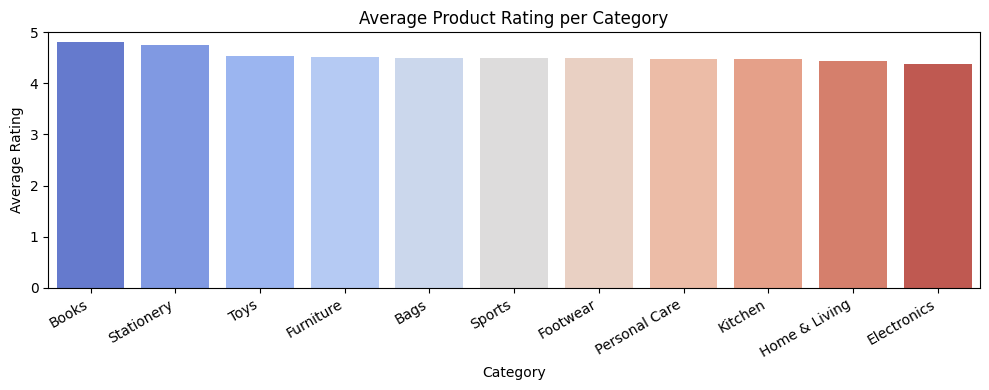

In [12]:
plt.figure(figsize=(10, 4))
avg_rating = df_products.groupby("category")["rating"].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="coolwarm")
plt.title("Average Product Rating per Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

C:\Users\mugha\AppData\Local\Temp\ipykernel_3708\2890569029.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="category", y="price", data=df_products, palette="Set2")


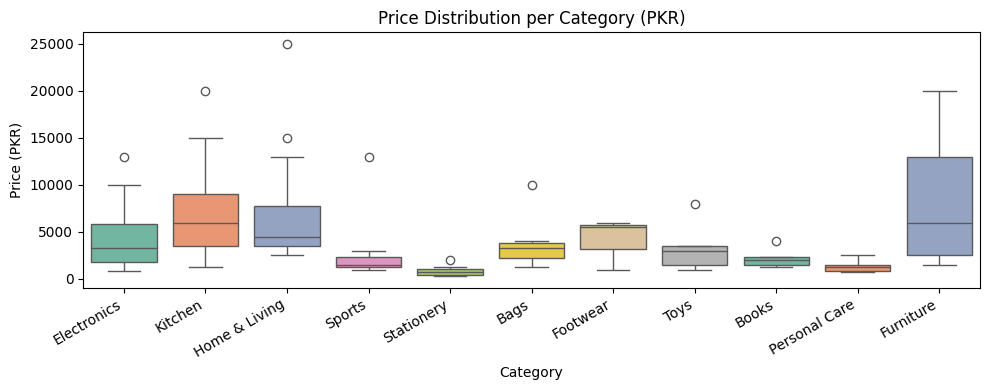

In [13]:
plt.figure(figsize=(10, 4))
sns.boxplot(x="category", y="price", data=df_products, palette="Set2")
plt.title("Price Distribution per Category (PKR)")
plt.xlabel("Category")
plt.ylabel("Price (PKR)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

C:\Users\mugha\AppData\Local\Temp\ipykernel_3708\4085291803.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="quantity", y="name", data=top_products, palette="Blues_r")


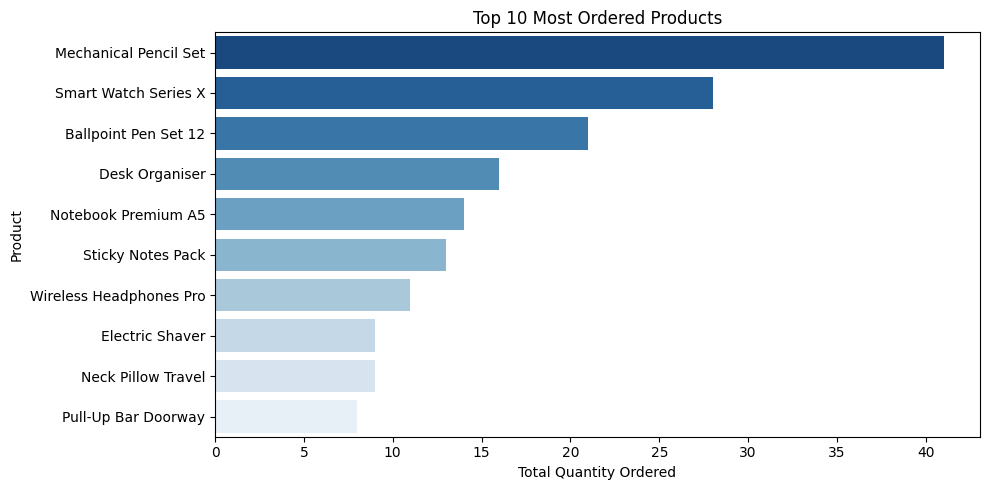

In [14]:
plt.figure(figsize=(10, 5))
top_products = (
    df_order_items.groupby("product_id")["quantity"]
    .sum()
    .reset_index()
    .merge(df_products[["id", "name"]], left_on="product_id", right_on="id")
    .sort_values("quantity", ascending=False)
    .head(10)
)
sns.barplot(x="quantity", y="name", data=top_products, palette="Blues_r")
plt.title("Top 10 Most Ordered Products")
plt.xlabel("Total Quantity Ordered")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

C:\Users\mugha\AppData\Local\Temp\ipykernel_3708\1509709486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette="muted")


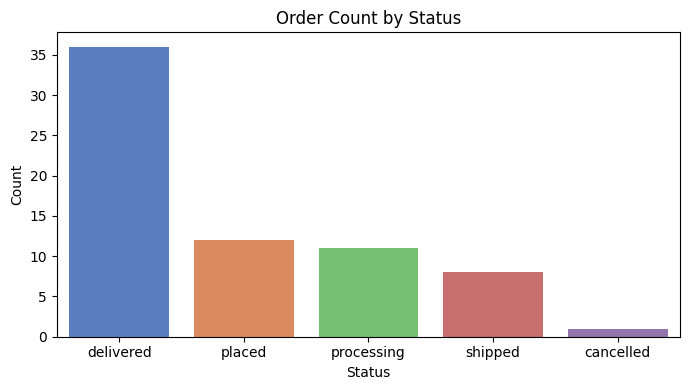

In [15]:
plt.figure(figsize=(7, 4))
status_counts = df_orders["status"].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, palette="muted")
plt.title("Order Count by Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

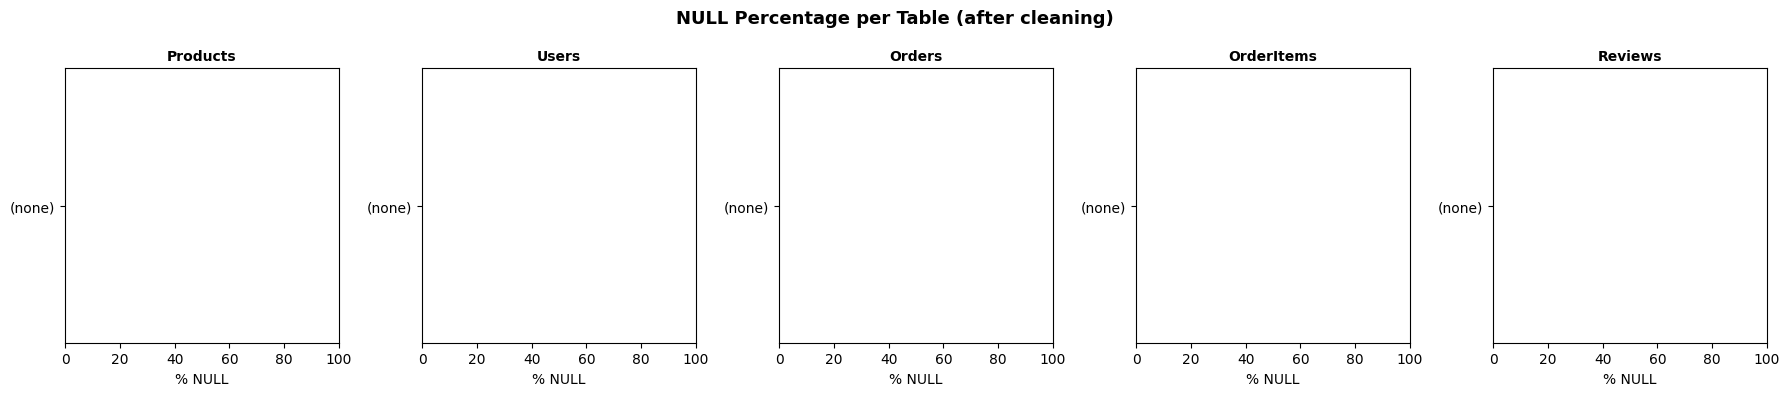

In [16]:
# NULL heatmap — should be all zeros after cleaning
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("NULL Percentage per Table (after cleaning)", fontsize=13, fontweight="bold")

tables = {
    "Products": df_products,
    "Users": df_users_clean,
    "Orders": df_orders,
    "OrderItems": df_order_items,
    "Reviews": df_reviews,
}

for ax, (name, df) in zip(axes, tables.items()):
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0] if any(null_pct > 0) else pd.Series([0], index=["(none)"])
    colors = ["#e74c3c" if v > 10 else "#f39c12" if v > 0 else "#27ae60" for v in null_pct.values]
    ax.barh(null_pct.index, null_pct.values, color=colors)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("% NULL")
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

## 7. Content-Based Filtering Model (KNN)

### Phase 1 - Build content column

In [17]:
# glue the 4 text fields into one string per product - this is what the model reads
df_products["content"] = (
    df_products["name"] + " " +
    df_products["category"] + " " +
    df_products["brand"] + " " +
    df_products["description"]
)
df_products["content"] = df_products["content"].str.lower().str.strip()
df_products[["name", "content"]].head(3)

,name,content
0,Wireless Headphones Pro,wireless headphones pro electronics soundmax b...
1,Noise Cancelling Earbuds,noise cancelling earbuds electronics soundmax ...
2,Portable Bluetooth Speaker,portable bluetooth speaker electronics soundma...


### Phase 2 - TF-IDF Vectorization

In [18]:
# --- Step 1: TF-IDF ---
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=5000,
    sublinear_tf=True,
    min_df=1,
)
tfidf_matrix = vectorizer.fit_transform(df_products['content'])
print('TF-IDF shape:', tfidf_matrix.shape)

# --- Step 2: TruncatedSVD ---
# Rule: n_components = ~sqrt(n_products), capped at 20 for catalogues < 200 products.
# 100 components on 101 products = 99.4% variance = model memorises, kills diversity.
# 15 components = ~60-70% variance = enough signal, leaves room for meaningful distances.
N_COMPONENTS = min(15, len(df_products) - 1)
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
text_matrix = svd.fit_transform(tfidf_matrix)
print(f'SVD compressed text matrix: {text_matrix.shape}')
print(f'Variance explained by SVD: {svd.explained_variance_ratio_.sum():.1%}')

# --- Step 3: Blend numeric features (rating + price) ---
scaler = MinMaxScaler()
numeric_features = scaler.fit_transform(df_products[['rating', 'price']].values)
# Weight = 2: numeric dims are 2 out of 17 total (12%) — enough to separate
# by price tier without overwhelming the text signal.
NUMERIC_WEIGHT = 2
combined_dense = np.hstack([text_matrix, numeric_features * NUMERIC_WEIGHT])

# --- Step 4: L2-normalize so cosine similarity = dot product ---
combined_matrix = normalize(combined_dense, norm='l2')
print('Final combined matrix shape:', combined_matrix.shape)

# Diagnostics
from sklearn.metrics.pairwise import cosine_similarity
sample = min(30, len(df_products))
sim = cosine_similarity(combined_matrix[:sample])
np.fill_diagonal(sim, 0)
print(f'Avg pairwise similarity: {sim.mean():.3f}  (target: 0.3-0.6)')
print(f'Min: {sim.min():.3f},  Max: {sim.max():.3f}')


TF-IDF shape: (101, 1764)
SVD compressed text matrix: (101, 15)
Variance explained by SVD: 20.1%
Final combined matrix shape: (101, 17)
Avg pairwise similarity: 0.597  (target: 0.3-0.6)
Min: -0.130,  Max: 0.993


### Phase 3 - Fit KNN Model (Content)

In [19]:
N_CONTENT_NEIGHBORS = min(6, len(df_products))
knn_content = NearestNeighbors(
    n_neighbors=N_CONTENT_NEIGHBORS,
    metric='cosine',
    algorithm='brute',
)
knn_content.fit(combined_matrix)
print(f'KNN fitted: {combined_matrix.shape[0]} products, '
      f'{combined_matrix.shape[1]} dims, {N_CONTENT_NEIGHBORS} neighbours')


KNN fitted: 101 products, 17 dims, 6 neighbours


### Phase 4 - Test function

In [20]:
product_index = pd.Series(df_products.index, index=df_products['name']).drop_duplicates()

def get_content_based_recommendations(product_name, num_recommendations=5):
    if product_name not in product_index:
        print(f'not found: {product_name}')
        return pd.DataFrame()
    idx = product_index[product_name]
    n_neighbors = min(num_recommendations + 1, combined_matrix.shape[0])
    distances, indices = knn_content.kneighbors(
        combined_matrix[idx].reshape(1, -1), n_neighbors=n_neighbors
    )
    rec_indices = indices[0][1:]
    rec_scores  = [round(1 - d, 4) for d in distances[0][1:]]
    result = df_products.iloc[rec_indices][['name', 'category', 'brand', 'price', 'rating']].copy()
    result['similarity_score'] = rec_scores
    return result.head(num_recommendations).reset_index(drop=True)

recs = get_content_based_recommendations('Wireless Headphones Pro')
print(recs.to_string())
print('\nScore range:', recs['similarity_score'].min(), '-', recs['similarity_score'].max())


                         name     category     brand   price  rating  similarity_score
0    Noise Cancelling Earbuds  Electronics  SoundMax  3999.0     4.6            0.9716
1  Portable Bluetooth Speaker  Electronics  SoundMax  3499.0     4.5            0.9678
2  Over-Ear Studio Headphones  Electronics  AudioPro  7999.0     4.7            0.9482
3        Wireless Charger 15W  Electronics  TechView  1999.0     4.3            0.9036
4  Bone Conduction Headphones  Electronics  AudioPro  5499.0     4.2            0.8726

Score range: 0.8726 - 0.9716


### Phase 5 - Save Content-Based Model Files

In [21]:
with open('knn_content.pkl', 'wb') as f:
    pkl.dump(knn_content, f)
with open('vectorizer.pkl', 'wb') as f:
    pkl.dump(vectorizer, f)
with open('svd.pkl', 'wb') as f:
    pkl.dump(svd, f)
with open('tfidf_matrix.pkl', 'wb') as f:
    pkl.dump(combined_matrix, f)
with open('feature_scaler.pkl', 'wb') as f:
    pkl.dump(scaler, f)
with open('numeric_weight.pkl', 'wb') as f:
    pkl.dump(NUMERIC_WEIGHT, f)
product_ids = df_products['id'].tolist()
with open('product_ids.pkl', 'wb') as f:
    pkl.dump(product_ids, f)
print('All content model files saved.')


All content model files saved.


## 8. Collaborative Filtering Model (KNN)

### Phase 1 - Build User-Item Matrix

In [22]:
# Join order_items with orders to get user_id for each purchase
user_item_df = df_order_items.merge(
    df_orders[['id', 'user_id']],
    left_on='order_id',
    right_on='id'
)

# Build raw purchase matrix: rows=users, cols=products, values=total qty bought
purchase_matrix = user_item_df.pivot_table(
    index='user_id',
    columns='product_id',
    values='quantity',
    aggfunc='sum',
    fill_value=0
)

# --- Incorporate review ratings as an explicit preference signal ---
# A user who bought AND rated 5-stars is a stronger signal than a user who
# just bought once. Blend: final_score = qty + (review_rating - 3) * boost
# (ratings 1-2 become negative, 4-5 become positive boosts)
REVIEW_BOOST = 0.5  # tune: higher = trust ratings more

review_pivot = df_reviews.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating',
    aggfunc='mean',   # average rating if somehow multiple reviews
    fill_value=3      # neutral (3 = no boost, no penalty)
)

# Align indices so we can add the two matrices
all_users = purchase_matrix.index.union(review_pivot.index)
all_prods = purchase_matrix.columns.union(review_pivot.columns)

purchase_aligned = purchase_matrix.reindex(index=all_users, columns=all_prods, fill_value=0)
review_aligned   = review_pivot.reindex(index=all_users, columns=all_prods, fill_value=3)

# Blend: purchase qty + (rating - 3) * boost
user_item_matrix = purchase_aligned + (review_aligned - 3) * REVIEW_BOOST
user_item_matrix = user_item_matrix.clip(lower=0)  # don't let bad reviews go negative

print('User-item matrix shape:', user_item_matrix.shape)
user_item_matrix.head()


User-item matrix shape: (16, 43)


product_id,1,3,7,8,9,11,12,13,19,29,...,70,71,72,73,78,80,83,84,90,91
user_id,,,,,,,,,,,,,,,,,,,,,
2,2.5,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
3,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,3.0,2.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0
5,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,2.5,0.0,0.0,0.0,2.0,1.0
6,3.0,0.0,0.0,0.0,0.0,0.0,3.0,5.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Phase 2 - Fit KNN Model (Users)

In [23]:
# Auto-scale n_neighbors for small datasets
N_COLLAB_NEIGHBORS = min(6, len(user_item_matrix))

knn_users = NearestNeighbors(
    n_neighbors=N_COLLAB_NEIGHBORS,
    metric='cosine',
    algorithm='brute',
)
knn_users.fit(user_item_matrix)
print(f'Collaborative KNN fitted on {user_item_matrix.shape[0]} users, '
      f'{user_item_matrix.shape[1]} products, {N_COLLAB_NEIGHBORS} neighbours')


Collaborative KNN fitted on 16 users, 43 products, 6 neighbours


### Phase 3 - Test function

In [24]:
def get_collaborative_recommendations(user_id, num_recommendations=5):
    if user_id not in user_item_matrix.index:
        print(f"user {user_id} not found")
        return pd.DataFrame()

    # get row index for this user and find their 6 nearest neighbours
    user_row_index = user_item_matrix.index.get_loc(user_id)
    user_vector = user_item_matrix.iloc[[user_row_index]]
    distances, indices = knn_users.kneighbors(user_vector)

    similar_user_indices = indices[0][1:]  # skip index 0 (the user themselves)
    similar_user_ids = user_item_matrix.index[similar_user_indices]

    # products this user already bought - we won't recommend these
    already_bought = set(user_item_matrix.columns[user_item_matrix.loc[user_id] > 0])

    product_scores = {}
    for i, sim_user_id in enumerate(similar_user_ids):
        sim_score = 1 - distances[0][i + 1]  # similarity = 1 - distance
        if sim_score <= 0:
            continue
        for pid, qty in user_item_matrix.loc[sim_user_id].items():
            if qty > 0 and pid not in already_bought:
                # weight the score by how similar the user is and how much they bought
                product_scores[pid] = product_scores.get(pid, 0) + (qty * sim_score)

    if not product_scores:
        return pd.DataFrame()

    top_ids = sorted(product_scores, key=product_scores.get, reverse=True)[:num_recommendations]
    result = df_products[df_products["id"].isin(top_ids)][["id", "name", "category", "brand", "price"]].copy()
    result["score"] = result["id"].map(lambda pid: round(product_scores.get(pid, 0), 4))
    return result.sort_values("score", ascending=False).reset_index(drop=True)

get_collaborative_recommendations(3)

,id,name,category,brand,price,score
0,43,Juicer Centrifugal,Kitchen,CookPro,4499.0,0.8583
1,7,Bone Conduction Headphones,Electronics,AudioPro,5499.0,0.7760
2,61,Pull-Up Bar Doorway,Sports,FitLife,2499.0,0.7545
3,67,Ballpoint Pen Set 12,Stationery,WriteOn,399.0,0.7015
4,80,Sneakers Women,Footwear,StepUp,5499.0,0.6671


### Phase 4 - Save Collaborative Model Files

In [25]:
with open("knn_users.pkl", "wb") as f:
    pkl.dump(knn_users, f)

with open("user_item_matrix.pkl", "wb") as f:
    pkl.dump(user_item_matrix, f)

print("saved")

saved


## 9. Hybrid Model

### Phase 1 - Combined Scoring

In [26]:
def get_hybrid_recommendations(user_id, product_id=None, num_recommendations=5):
    hybrid_scores = {}
    content_w = 0.5
    collab_w  = 0.5

    if product_id is not None and product_id in product_ids:
        idx = product_ids.index(product_id)
        n_neighbors = min(6, combined_matrix.shape[0])
        distances, indices = knn_content.kneighbors(
            combined_matrix[idx].reshape(1, -1), n_neighbors=n_neighbors
        )
        for dist, rec_idx in zip(distances[0][1:], indices[0][1:]):
            pid = product_ids[rec_idx]
            hybrid_scores[pid] = hybrid_scores.get(pid, 0) + ((1 - dist) * content_w)

    if user_id in user_item_matrix.index:
        user_row_index = user_item_matrix.index.get_loc(user_id)
        user_vector = user_item_matrix.iloc[[user_row_index]]
        n_neighbors = min(6, len(user_item_matrix))
        distances, indices = knn_users.kneighbors(user_vector, n_neighbors=n_neighbors)
        similar_user_indices = indices[0][1:]
        similar_user_ids = user_item_matrix.index[similar_user_indices]
        already_bought = set(user_item_matrix.columns[user_item_matrix.loc[user_id] > 0])
        for i, sim_user_id in enumerate(similar_user_ids):
            sim_score = 1 - distances[0][i + 1]
            if sim_score <= 0:
                continue
            for pid, qty in user_item_matrix.loc[sim_user_id].items():
                if qty > 0 and pid not in already_bought:
                    hybrid_scores[pid] = hybrid_scores.get(pid, 0) + (qty * sim_score * collab_w)

    if not hybrid_scores:
        return pd.DataFrame()

    top_ids = sorted(hybrid_scores, key=hybrid_scores.get, reverse=True)[:num_recommendations]
    result = df_products[df_products['id'].isin(top_ids)][['id', 'name', 'category', 'brand', 'price']].copy()
    result['hybrid_score'] = result['id'].map(lambda pid: round(hybrid_scores.get(pid, 0), 4))
    return result.sort_values('hybrid_score', ascending=False).reset_index(drop=True)

get_hybrid_recommendations(user_id=3, product_id=1)


,id,name,category,brand,price,hybrid_score
0,7,Bone Conduction Headphones,Electronics,AudioPro,5499.0,0.8243
1,3,Portable Bluetooth Speaker,Electronics,SoundMax,3499.0,0.7444
2,2,Noise Cancelling Earbuds,Electronics,SoundMax,3999.0,0.4858
3,4,Over-Ear Studio Headphones,Electronics,AudioPro,7999.0,0.4741
4,26,Wireless Charger 15W,Electronics,TechView,1999.0,0.4518


### Phase 2 - Save Hybrid Weights

In [27]:
# Now that the collaborative model incorporates review ratings (richer signal),
# we raise its weight slightly. 50/50 is a safe balanced starting point.
# Tune these weights based on A/B test click-through results in production.
hybrid_weights = {'content_w': 0.5, 'collab_w': 0.5}
with open('hybrid_weights.pkl', 'wb') as f:
    pkl.dump(hybrid_weights, f)
print('Saved hybrid_weights:', hybrid_weights)


Saved hybrid_weights: {'content_w': 0.5, 'collab_w': 0.5}


## 10. Model Comparison Summary

In [28]:
print("Content-Based : TF-IDF + KNN  -> product detail page")
print("Collaborative : user-item KNN  -> homepage")
print("Hybrid        : 40/60 mix      -> homepage (logged in)")

Content-Based : TF-IDF + KNN  -> product detail page
Collaborative : user-item KNN  -> homepage
Hybrid        : 40/60 mix      -> homepage (logged in)


## 11. Model Performance Visualization

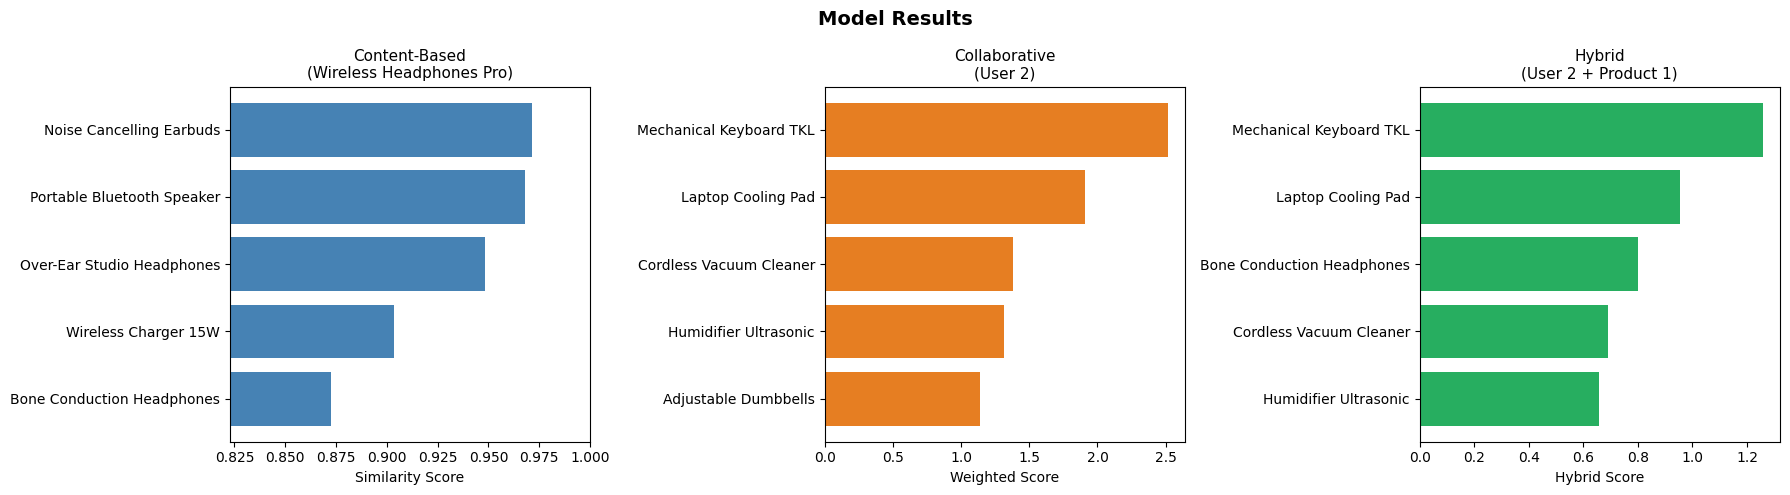

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Results', fontsize=14, fontweight='bold')

# Content-based
cb = get_content_based_recommendations('Wireless Headphones Pro')
if not cb.empty:
    axes[0].barh(cb['name'], cb['similarity_score'], color='steelblue')
    axes[0].set_title('Content-Based\n(Wireless Headphones Pro)', fontsize=11)
    axes[0].set_xlabel('Similarity Score')
    axes[0].invert_yaxis()
    # Set x-axis to actual score range so differences are visible
    score_min = max(0, cb['similarity_score'].min() - 0.05)
    axes[0].set_xlim(score_min, 1.0)

# Collaborative
user_test_id = user_item_matrix.index[0]
cf = get_collaborative_recommendations(user_test_id)
if not cf.empty:
    axes[1].barh(cf['name'], cf['score'], color='#e67e22')
    axes[1].set_title(f'Collaborative\n(User {user_test_id})', fontsize=11)
    axes[1].set_xlabel('Weighted Score')
    axes[1].invert_yaxis()

# Hybrid
hy = get_hybrid_recommendations(user_id=user_test_id, product_id=1)
if not hy.empty:
    axes[2].barh(hy['name'], hy['hybrid_score'], color='#27ae60')
    axes[2].set_title(f'Hybrid\n(User {user_test_id} + Product 1)', fontsize=11)
    axes[2].set_xlabel('Hybrid Score')
    axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


## 12. Recommendation Quality Metrics

Basic offline metrics to evaluate model quality without a live A/B test.

In [30]:
# --- Coverage: what fraction of the product catalogue gets recommended? ---
# Low coverage = the model keeps recommending the same popular items.

recommended_content_ids = set()
for name in df_products['name'].sample(min(20, len(df_products)), random_state=42):
    recs = get_content_based_recommendations(name, num_recommendations=5)
    if not recs.empty:
        matched = df_products[df_products['name'].isin(recs['name'])]['id']
        recommended_content_ids.update(matched.tolist())

content_coverage = len(recommended_content_ids) / len(df_products)
print(f'Content-based catalogue coverage: {content_coverage:.1%}')

# --- Intra-list diversity: avg pairwise category diversity in a rec list ---
# High diversity = recommendations span multiple categories (good for discovery).
diversity_scores = []
for name in df_products['name'].sample(min(10, len(df_products)), random_state=0):
    recs = get_content_based_recommendations(name, num_recommendations=5)
    if not recs.empty and 'category' in recs.columns:
        n_unique_cats = recs['category'].nunique()
        diversity_scores.append(n_unique_cats / len(recs))

avg_diversity = np.mean(diversity_scores) if diversity_scores else 0
print(f'Avg intra-list category diversity: {avg_diversity:.2f} '
      f'(1.0 = all different categories, 0.2 = all same)')

# --- Cold-start coverage: users with <2 orders ---
user_order_counts = df_order_items.merge(
    df_orders[['id','user_id']], left_on='order_id', right_on='id'
).groupby('user_id')['order_id'].nunique()

cold_users = user_order_counts[user_order_counts < 2].index
cold_in_matrix = cold_users.isin(user_item_matrix.index).sum()
print(f'Cold-start users (<2 orders): {len(cold_users)}, '
      f'represented in collab matrix: {cold_in_matrix}')
print('Tip: cold-start users will fall back to content-based or trending recs in app.py')


Content-based catalogue coverage: 64.4%
Avg intra-list category diversity: 0.40 (1.0 = all different categories, 0.2 = all same)
Cold-start users (<2 orders): 1, represented in collab matrix: 1
Tip: cold-start users will fall back to content-based or trending recs in app.py
